In [ ]:
# 📌 Install required libraries
!pip install transformers torch scikit-learn pandas numpy spacy seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# 📌 Download Spacy English Model
import spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import spacy
import string


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

In [ ]:
# ✅ Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


   Serial_Number                                       Poem_Content Poem_Type
0              1  On moonlit heath and lonesome bank The sheep b...     Death
1              2  “Lights out" along the land, “Lights out” upon...     Death
2              3  I am a garden of red tulips And late daffodils...     Death
3              4  New moon in midheaven, in Libra. The hermit wi...     Death
4              5  All the hills and vales alongEarth is bursting...     Death


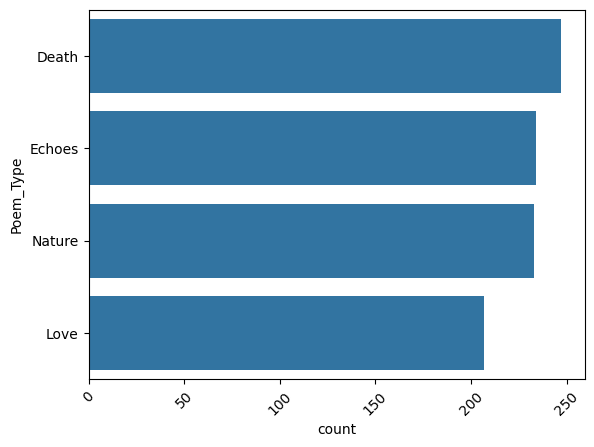

In [ ]:
# 📌 Load the dataset
data = pd.read_csv('/content/nlpDataFinal.csv')

# 📌 Check data structure
print(data.head())

# 📌 Visualize Poem Types Distribution
sns.countplot(data['Poem_Type'])
plt.xticks(rotation=45)
plt.show()


In [ ]:
# ✅ Load Spacy Model
nlp = spacy.load('en_core_web_sm')

# ✅ Define preprocessing functions
punc = string.punctuation + '“”|”'

def remove_stop_words(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if not token.is_stop])

def to_lower(text):
    return text.lower()

def remove_punc(text):
    for i in punc:
        text = text.replace(i,"")
    return text

# ✅ Apply preprocessing
data['Poem_Content'] = data['Poem_Content'].apply(to_lower)
data['Poem_Content'] = data['Poem_Content'].apply(remove_punc)
data['Tokens'] = data['Poem_Content'].apply(remove_stop_words)

print(data.head())


   Serial_Number                                       Poem_Content Poem_Type  \
0              1  on moonlit heath and lonesome bank the sheep b...     Death   
1              2  lights out along the land lights out upon the ...     Death   
2              3  i am a garden of red tulips and late daffodils...     Death   
3              4  new moon in midheaven in libra the hermit wiel...     Death   
4              5  all the hills and vales alongearth is bursting...     Death   

                                              Tokens  
0  moonlit heath lonesome bank sheep graze yon ga...  
1  light land light sea night hiding hand o’er pe...  
2  garden red tulip late daffodil bayhedge small ...  
3  new moon midheaven libra hermit wield sword te...  
4  hill vale alongearth burst songand singer chap...  


In [ ]:
# ✅ Prepare Training & Test Data
X = data['Tokens']
y = data['Poem_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=100)

# ✅ Vectorization using CountVectorizer
vect = CountVectorizer(min_df=2, max_df=0.95, stop_words='english')
dtm = vect.fit_transform(X_train)
dtm2 = vect.transform(X_test)

# ✅ Apply Latent Dirichlet Allocation (LDA)
LDA = LatentDirichletAllocation(n_components=4, random_state=100)
lda_train_features = LDA.fit_transform(dtm)
lda_test_features = LDA.transform(dtm2)

# ✅ Train an SVM Classifier
theme_classifier = Pipeline([
    ("Tfidf", TfidfVectorizer(min_df=2, max_df=0.95)),
    ("ToDense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
    ("Classifier", SVC(gamma=0.0001, kernel='linear'))
])

theme_classifier.fit(X_train, lda_train_features.argmax(axis=1))
predictions = theme_classifier.predict(X_test)

# ✅ Evaluate Model
accuracy = accuracy_score(lda_test_features.argmax(axis=1), predictions)
print(f'🎯 Theme Classification Accuracy: {accuracy * 100:.2f}%')


🎯 Theme Classification Accuracy: 71.00%


In [ ]:
# ✅ Load Model
#model_path = "EleutherAI/gpt-j-6B"
model_path = "mosaicml/mpt-7b-instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🔄 Loading model on {device}...")

# ✅ Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)

# ✅ Load model with offloading folder
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    offload_folder="offload_weights"  # 🔹 Specify offload folder
)

# ✅ Create text-generation pipeline
interpretation_pipeline = pipeline("text-generation", model=model, tokenizer=tokenizer)

print(f"✅ Model Loaded!")

🔄 Loading model on cuda...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/16.8k [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


✅ Model Loaded!


In [ ]:
theme_labels = {
    0: "Death",
    1: "Echoes",
    2: "Nature",
    3: "Love"
}

def predict_theme(poem_text):
    #print(f"DEBUG: Received poem_text in predict_theme - Type: {type(poem_text)}")

    poem_text = str(poem_text)
    #print(f"DEBUG: Converted poem_text in predict_theme - Type: {type(poem_text)}, Value: {poem_text}")

    processed_poem = remove_stop_words(remove_punc(to_lower(poem_text)))
    #print(f"DEBUG: Processed poem - Type: {type(processed_poem)}, Value: {processed_poem}")

    predicted_label = theme_classifier.predict([processed_poem])
    #print(f"DEBUG: Raw predicted theme - Type: {type(predicted_label)}, Value: {predicted_label}")

    # Convert numpy array to scalar
    predicted_label = int(predicted_label[0]) if isinstance(predicted_label, np.ndarray) else int(predicted_label)

    # Convert numeric label to text
    theme_str = theme_labels.get(predicted_label, "Unknown Theme")

    #print(f"DEBUG: Final predicted theme - Type: {type(theme_str)}, Value: {theme_str}")

    return theme_str


# 📌 Function to Generate Interpretation
def generate_interpretation(poem_text):
    # Debugging print to check input type
    #print(f"DEBUG: Received poem_text in generate_interpretation - Type: {type(poem_text)}")

    # Ensure poem_text is a string
    if isinstance(poem_text, np.ndarray):
        poem_text = poem_text.item()  # Convert NumPy array to scalar

    poem_text = str(poem_text)  # Final conversion to string

    # Debugging print after conversion
    #print(f"DEBUG: Converted poem_text in generate_interpretation - Type: {type(poem_text)}, Value: {poem_text}")

    theme = predict_theme(poem_text)

    # Debugging print
    #print(f"DEBUG: Predicted Theme Type: {type(theme)}, Value: {theme}")

    prompt = f"The following poem is about {theme}. Interpret its meaning:\n\n{poem_text}\n\nInterpretation:"

    print(f"🔹 Predicted Theme: {theme}")

    # Call the actual pipeline (replace with your real function)
    result = interpretation_pipeline(prompt, max_length=250, do_sample=True, temperature=0.7, top_p=0.9, repetition_penalty=1.2)

    # Ensure correct text extraction from generated output
    generated_text = result[0]['generated_text']
    interpretation = generated_text.split("Interpretation:")[-1].strip()

    return interpretation


In [ ]:
# 📝 Example Poem
poem = """A Bird came down the Walk –
He did not know I saw –
He bit an Angleworm in halves
And ate the fellow, raw.

And then he drank a Dew
From a convenient Grass –
And then hopped sidewise to the Wall
To let a Beetle pass –"""

# 🔹 Predict Theme & Generate Interpretation
interpretation = generate_interpretation(poem)
print("\n📖 Interpretation:\n", interpretation)


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


🔹 Predicted Theme: Death

📖 Interpretation:
 The bird represents death as it comes unexpectedly and takes life away without any warning or remorse for those who are left behind on earth (the angle worm). It also shows that even if you try your best at avoiding something bad from happening by being careful around nature - there's no way of knowing what will happen next because "death" can strike anywhere anytime


In [ ]:
poem = """His tongue shorn, father confusessnacks for snakes, kitchen for chicken.It is 1992. Weekends, we paw at cheapsilverware at yard sales. I am told by motherto keep our telephone number close,my beaded coin purse closer. I do this.The years are slow to pass, heavy-footed.Because the visits are frequent, we memorizeshameâ€™s numbing"""

interpretation = generate_interpretation(poem)
print("\n📖 Interpretation:\n", interpretation)

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


🔹 Predicted Theme: Echoes

📖 Interpretation:
 The poet uses a metaphor of his childhood as "echoing" in order that he can convey memories from then with him into adulthood and beyond; though some things may have changed over time (silver ware becomes cheap), they remain clear through association


In [ ]:
!pip install fastapi uvicorn flask-cors pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.2 MB/s eta 0:00:00


In [ ]:
theme_labels = {
    0: "Death",
    1: "Echoes",
    2: "Nature",
    3: "Love"
}

def predict_theme2(poem_text):
    #print(f"DEBUG: Received poem_text in predict_theme - Type: {type(poem_text)}")

    poem_text = str(poem_text)
    #print(f"DEBUG: Converted poem_text in predict_theme - Type: {type(poem_text)}, Value: {poem_text}")

    processed_poem = remove_stop_words(remove_punc(to_lower(poem_text)))
    #print(f"DEBUG: Processed poem - Type: {type(processed_poem)}, Value: {processed_poem}")

    predicted_label = theme_classifier.predict([processed_poem])
    #print(f"DEBUG: Raw predicted theme - Type: {type(predicted_label)}, Value: {predicted_label}")

    # Convert numpy array to scalar
    predicted_label = int(predicted_label[0]) if isinstance(predicted_label, np.ndarray) else int(predicted_label)

    # Convert numeric label to text
    theme_str = theme_labels.get(predicted_label, "Unknown Theme")

    #print(f"DEBUG: Final predicted theme - Type: {type(theme_str)}, Value: {theme_str}")

    return theme_str


# 📌 Function to Generate Interpretation
def generate_interpretation2(poem_text):
    # Debugging print to check input type
    #print(f"DEBUG: Received poem_text in generate_interpretation - Type: {type(poem_text)}")

    # Ensure poem_text is a string
    if isinstance(poem_text, np.ndarray):
        poem_text = poem_text.item()  # Convert NumPy array to scalar

    poem_text = str(poem_text)  # Final conversion to string

    # Debugging print after conversion
    #print(f"DEBUG: Converted poem_text in generate_interpretation - Type: {type(poem_text)}, Value: {poem_text}")

    theme = predict_theme2(poem_text)

    # Debugging print
    #print(f"DEBUG: Predicted Theme Type: {type(theme)}, Value: {theme}")

    prompt = f"The following poem is about {theme}. Interpret its meaning:\n\n{poem_text}\n\nInterpretation:"

    print(f"🔹 Predicted Theme: {theme}")

    # Call the actual pipeline (replace with your real function)
    result = interpretation_pipeline(prompt, max_length=250, do_sample=True, temperature=0.7, top_p=0.9, repetition_penalty=1.2)

    # Ensure correct text extraction from generated output
    generated_text = result[0]['generated_text']
    interpretation = generated_text.split("Interpretation:")[-1].strip()

    return theme, interpretation


In [ ]:
# !rm -f ngrok ngrok-stable-linux-amd64.zip  # Remove old ngrok
# !wget -c -O ngrok.zip "https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.zip"
# !unzip -o ngrok.zip
# !./ngrok config add-authtoken 2nmltsPUlNSc9H2PHoADQrZAT3F_7XQPiBMQnhGHVgbAqqRY8

--2025-03-31 15:12:16--  https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.zip
Resolving bin.equinox.io (bin.equinox.io)... 99.83.220.108, 13.248.244.96, 75.2.60.68, ...
Connecting to bin.equinox.io (bin.equinox.io)|99.83.220.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9432536 (9.0M) [application/octet-stream]
Saving to: ‘ngrok.zip’

ngrok.zip           100%[===================>]   9.00M  13.1MB/s    in 0.7s    

2025-03-31 15:12:17 (13.1 MB/s) - ‘ngrok.zip’ saved [9432536/9432536]

Archive:  ngrok.zip
  inflating: ngrok                   
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
# !pkill -f ngrok
# !./ngrok http 5000 > /dev/null 2>&1 &

# !ps aux | grep ngrok


root        4228  0.0  0.2 1254492 30640 ?       Rl   09:34   0:00 ./ngrok http 5000
root        4238  0.0  0.0   7376  3496 ?        S    09:34   0:00 /bin/bash -c ps aux | grep ngrok
root        4240  0.0  0.0   6484  2396 ?        S    09:34   0:00 grep ngrok


In [ ]:
# !curl -s http://localhost:4040/api/tunnels | grep -o '"https://[^"]*"' | sed 's/"//g'

https://59fa-34-19-119-220.ngrok-free.app


In [ ]:
!pip install fastapi uvicorn pyngrok nest_asyncio

In [ ]:
!rm -f ngrok ngrok-stable-linux-amd64.zip  # Remove old ngrok
!wget -c -O ngrok.zip "https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.zip"
!unzip -o ngrok.zip
!./ngrok config add-authtoken AUTH_TOKEN #add ngrok authtoken here

--2025-04-02 04:55:25--  https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.zip
Resolving bin.equinox.io (bin.equinox.io)... 99.83.220.108, 35.71.179.82, 13.248.244.96, ...
Connecting to bin.equinox.io (bin.equinox.io)|99.83.220.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9432536 (9.0M) [application/octet-stream]
Saving to: ‘ngrok.zip’

ngrok.zip           100%[===================>]   9.00M  12.6MB/s    in 0.7s    

2025-04-02 04:55:26 (12.6 MB/s) - ‘ngrok.zip’ saved [9432536/9432536]

Archive:  ngrok.zip
  inflating: ngrok                   
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:


from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn
from pyngrok import ngrok
import nest_asyncio

# ✅ Initialize FastAPI
app = FastAPI()

# ✅ Define Request Model
class PoemRequest(BaseModel):
    poem: str

# ✅ Route to Predict Theme & Interpretation
@app.post("/predict/")
async def predict(poem_request: PoemRequest):
    poem_text = poem_request.poem
    theme = predict_theme2(poem_text)
    theme, interpretation = generate_interpretation2(poem_text)
    return {"theme": theme, "interpretation": interpretation}

# ✅ Start ngrok on port 8000
public_url = ngrok.connect(8000).public_url
print(f"🚀 FastAPI is running on {public_url}")

# ✅ Fix asyncio issue in Colab
nest_asyncio.apply()

# ✅ Start FastAPI Server
uvicorn.run(app, host="0.0.0.0", port=8000)


INFO:     Started server process [368]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


🚀 FastAPI is running on https://5888-34-105-66-2.ngrok-free.app


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


🔹 Predicted Theme: Death
INFO:     122.15.186.196:0 - "POST /predict/ HTTP/1.1" 200 OK


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


🔹 Predicted Theme: Death
INFO:     122.15.186.196:0 - "POST /predict/ HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [368]
